<center>
    
## Fake News Detection Using Machine Learning
## Arulsree Mozhi, Thnagaraj Santhakumar

</center>

Dataset shape: (44898, 3)
label
FAKE    23481
REAL    21417
Name: count, dtype: int64


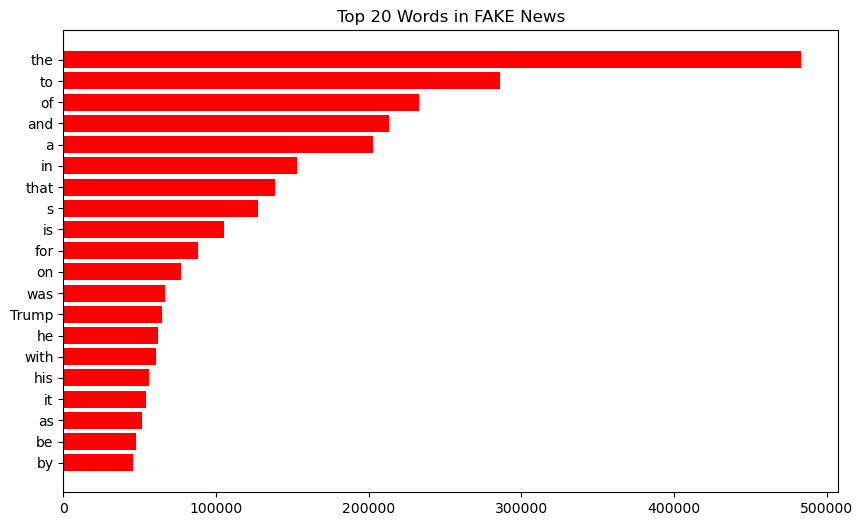

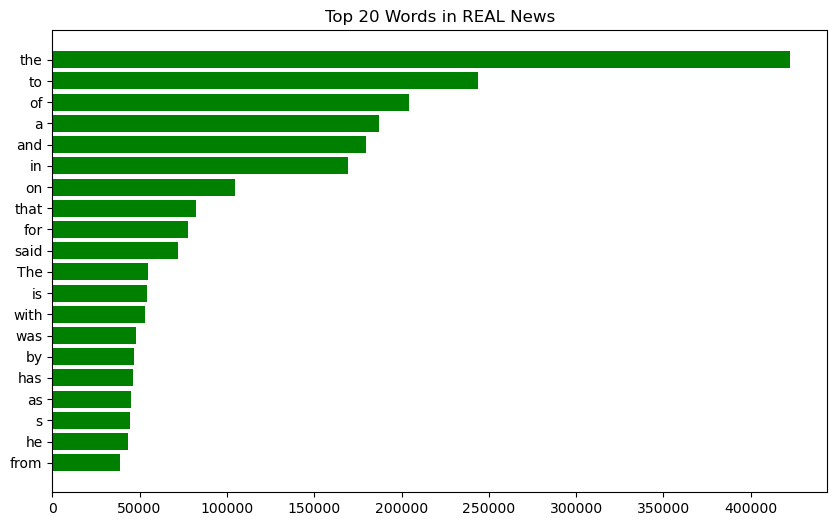

C:\Users\say_f\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


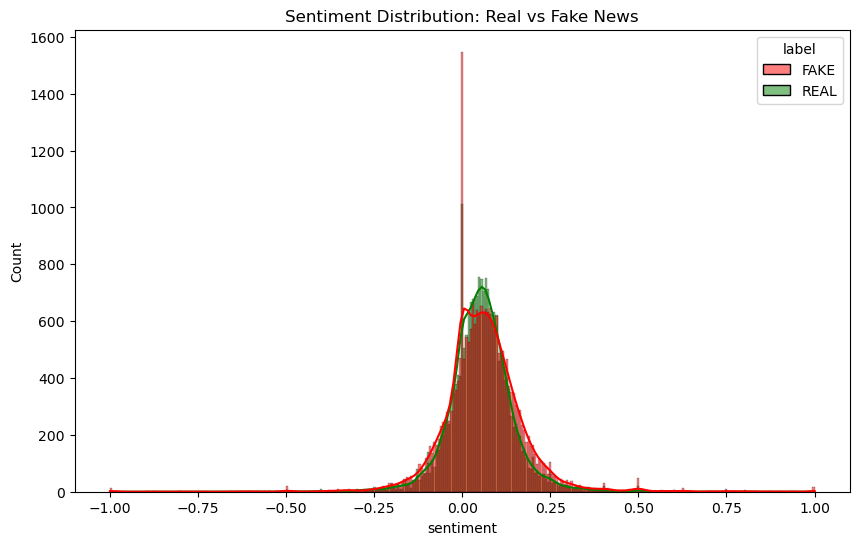

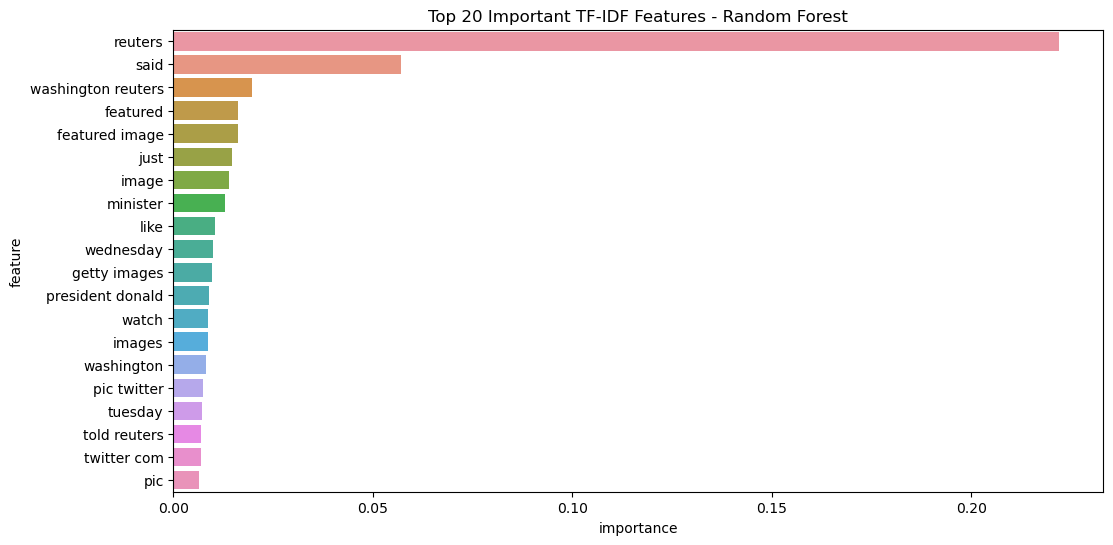

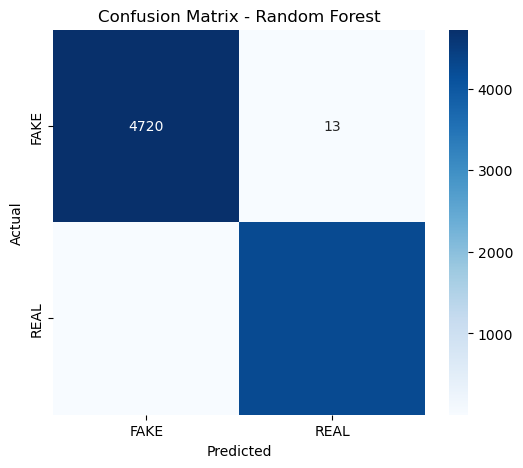

Classification Report:

              precision    recall  f1-score   support

        FAKE       1.00      1.00      1.00      4733
        REAL       1.00      1.00      1.00      4247

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



In [1]:
# -----------------------
# Required Libraries
# -----------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from textblob import TextBlob
from collections import Counter

# -----------------------
# 1. Load Data
# -----------------------
fake = pd.read_csv('dataset_sample_1.csv') #fake dataset
true = pd.read_csv('dataset_sample_2.csv') #true dataset

fake['label'] = 'FAKE'
true['label'] = 'REAL'

df = pd.concat([fake, true], ignore_index=True)
df = df[['title','text','label']]
df['text'] = df['text'].fillna('')

print("Dataset shape:", df.shape)
print(df['label'].value_counts())

# -----------------------
# 2. Word Frequency Bar Charts
# -----------------------
def plot_top_words(data, label, top_n=20, save_path=None):
    words = " ".join(data[data['label']==label]['text']).split()
    counter = Counter(words)
    top_words = counter.most_common(top_n)
    words_list, counts = zip(*top_words)
    
    plt.figure(figsize=(10,6))
    plt.barh(words_list, counts, color='red' if label=='FAKE' else 'green')
    plt.title(f"Top {top_n} Words in {label} News")
    plt.gca().invert_yaxis()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()

plot_top_words(df, 'FAKE', save_path='top_words_fake.png')
plot_top_words(df, 'REAL', save_path='top_words_real.png')

# -----------------------
# 3. Sentiment Analysis
# -----------------------
def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

df['sentiment'] = df['text'].apply(get_sentiment)

plt.figure(figsize=(10,6))
sns.histplot(df, x='sentiment', hue='label', kde=True, palette=['red','green'])
plt.title('Sentiment Distribution: Real vs Fake News')
plt.savefig('sentiment_distribution.png', bbox_inches='tight')
plt.show()

# -----------------------
# 4. TF-IDF Feature Extraction & Random Forest
# -----------------------
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words='english')
X = tfidf.fit_transform(df['text']).toarray()
y = df['label'].map({'FAKE':0, 'REAL':1}).values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# -----------------------
# 5. Top TF-IDF Features
# -----------------------
importances = rf.feature_importances_
feature_names = tfidf.get_feature_names_out()
feat_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_df = feat_df.sort_values(by='importance', ascending=False).head(20)

plt.figure(figsize=(12,6))
sns.barplot(x='importance', y='feature', data=feat_df)
plt.title('Top 20 Important TF-IDF Features - Random Forest')
plt.savefig('top_tfidf_features.png', bbox_inches='tight')
plt.show()

# -----------------------
# 6. Confusion Matrix & Metrics
# -----------------------
y_pred = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['FAKE','REAL'], yticklabels=['FAKE','REAL'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Random Forest')
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

# Classification Report
report = classification_report(y_test, y_pred, target_names=['FAKE','REAL'])
print("Classification Report:\n")
print(report)

# Optional: save classification report to a text file
with open('classification_report.txt', 'w') as f:
    f.write(report)
